# AI Quantum 2026 — DRL Model Engine Pipeline Notebook

Notebook này minh họa quy trình hoạt động hoàn chỉnh của **Model Engine**:
1. **Lấy dữ liệu + In ra bảng**: Truy vấn dữ liệu OHLCV & chỉ báo kỹ thuật từ Database/DuckDB cho các tập **Train**, **Validation**, và **Test Set (Out-of-Sample)** với lịch sử nung nóng (Lookback Warm-up), làm sạch dữ liệu qua `DataProcessor` và hiển thị bảng thông số.
2. **Train model**: Khởi tạo môi trường giao dịch `StockTradingEnv`, huấn luyện tập hợp mô hình DRL (`A2C`, `PPO`, `DDPG`) từ cấu hình `MODEL_CONFIG` (`config/model.yaml`), tự động chọn mô hình tối ưu theo Sharpe Ratio trên tập Validation, sau đó **kiểm thử out-of-sample trên tập TEST SET**.
3. **Trực quan kết quả**: Đánh giá hiệu năng danh mục trên **Tập TEST SET**, tính toán các chỉ số tài chính (Sharpe, Sortino, Max Drawdown) và trực quan hóa kết quả qua `ModelVisualizer`.

In [1]:
import os
import sys
import pandas as pd
import numpy as np

# Tự động tích hợp IPython display nếu chạy ngoài môi trường notebook
try:
    from IPython.display import display, Image
except ImportError:
    display = print

# Thiết lập sys.path để import các module từ pipeline và root
notebook_dir = os.path.dirname(os.path.abspath("__file__")) if "__file__" in locals() else os.getcwd()
pipeline_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
project_root = os.path.abspath(os.path.join(notebook_dir, "../../.."))

for p in [pipeline_dir, project_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

from model_engine.data.data_service import DataQueryService
from model_engine.data.processor import DataProcessor
from model_engine.env.stock_trading_env import StockTradingEnv
from model_engine.models.drl_models import DRLEnsembleStrategy
from model_engine.analysis.visualization import ModelVisualizer
from core.config.settings import MODEL_CONFIG

print("✅ Khởi tạo hệ thống và import thành công các mô-đun từ Model Engine!")

✅ Khởi tạo hệ thống và import thành công các mô-đun từ Model Engine!


## 1. Lấy dữ liệu + In ra bảng

In [2]:
# 1. Khởi tạo DataQueryService
data_service = DataQueryService()

# 2. Truy vấn khoảng thời gian Train, Validation và Test trực tiếp từ MODEL_CONFIG (config/model.yaml)
train_start = MODEL_CONFIG.get("train_start_date", "2018-08-06")
train_end = MODEL_CONFIG.get("train_end_date", "2022-12-31")
val_start = MODEL_CONFIG.get("val_start_date", "2023-01-01")
val_end = MODEL_CONFIG.get("val_end_date", "2023-12-31")
test_start = MODEL_CONFIG.get("test_start_date", "2024-01-01")
test_end = MODEL_CONFIG.get("test_end_date", "2024-12-31")

print(f"📥 Đang lấy dữ liệu Train ({train_start} -> {train_end}) kèm lịch sử nung nóng...")
raw_train_df = data_service.fetch_data(train_start, train_end, lookback_days=45)

print(f"📥 Đang lấy dữ liệu Validation ({val_start} -> {val_end}) kèm lịch sử nung nóng...")
raw_val_df = data_service.fetch_data(val_start, val_end, lookback_days=45)

print(f"📥 Đang lấy dữ liệu Test ({test_start} -> {test_end}) kèm lịch sử nung nóng...")
raw_test_df = data_service.fetch_data(test_start, test_end, lookback_days=45)

print(f"📥 Đang lấy dữ liệu Benchmark VN30 giai đoạn Test ({test_start} -> {test_end})...")
bm_test_df = data_service.fetch_symbol_data("VN30", test_start, test_end)

# 3. Tiền xử lý dữ liệu với DataProcessor (Z-Score chuẩn hóa và tự động lọc bỏ phần warm-up)
features = MODEL_CONFIG.get("features", ["RSI", "PPO", "CCI", "ADX", "ATR", "VOLATILITY", "YIELD_CURVE_SLOPE", "DXY_LOG_RETURN", "VN3YT"])

train_df = DataProcessor(raw_train_df, features).clean_data(start_date=train_start)
val_df = DataProcessor(raw_val_df, features).clean_data(start_date=val_start)
test_df = DataProcessor(raw_test_df, features).clean_data(start_date=test_start)

# 4. In ra bảng thông số dữ liệu tổng quan
summary_info = {
    "Tập dữ liệu": ["Train Set", "Validation Set", "Test Set (Out-of-Sample)", "Benchmark VN30 (Test)"],
    "Số dòng": [len(train_df), len(val_df), len(test_df), len(bm_test_df)],
    "Từ ngày": [train_start, val_start, test_start, test_start],
    "Đến ngày": [train_end, val_end, test_end, test_end],
    "Số Tickers": [
        train_df["tic"].nunique() if "tic" in train_df.columns else 0,
        val_df["tic"].nunique() if "tic" in val_df.columns else 0,
        test_df["tic"].nunique() if "tic" in test_df.columns else 0,
        bm_test_df["tic"].nunique() if not bm_test_df.empty and "tic" in bm_test_df.columns else 1
    ]
}
summary_df = pd.DataFrame(summary_info)

print("\n📊 TỔNG QUAN CÁC BỘ DỮ LIỆU SAU KHI NUNG NÓNG VÀ LỌC LỊCH SỬ:")
display(summary_df)

print("\n🔍 PREVIEW 10 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU TRAIN (TỪ NGÀY BẮT ĐẦU CHÍNH THỨC):")
display(train_df.head(10))

📥 Đang lấy dữ liệu Train (2018-08-06 -> 2022-12-31) kèm lịch sử nung nóng...
📥 Đang lấy dữ liệu Validation (2023-01-01 -> 2023-12-31) kèm lịch sử nung nóng...
📥 Đang lấy dữ liệu Test (2024-01-01 -> 2024-12-31) kèm lịch sử nung nóng...
📥 Đang lấy dữ liệu Benchmark VN30 giai đoạn Test (2024-01-01 -> 2024-12-31)...


/Users/khanhba89/Documents/NEU/ai_quantum_2026/src/pipeline/model_engine/data/processor.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('tic', group_keys=False).apply(lambda x: x.ffill()).reset_index(drop=True)
/Users/khanhba89/Documents/NEU/ai_quantum_2026/src/pipeline/model_engine/data/processor.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('tic', group_keys=False).apply(


📊 TỔNG QUAN CÁC BỘ DỮ LIỆU SAU KHI NUNG NÓNG VÀ LỌC LỊCH SỬ:


/Users/khanhba89/Documents/NEU/ai_quantum_2026/src/pipeline/model_engine/data/processor.py:89: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('tic', group_keys=False).apply(lambda x: x.ffill()).reset_index(drop=True)


,Tập dữ liệu,Số dòng,Từ ngày,Đến ngày,Số Tickers
0,Train Set,11050,2018-08-06,2022-12-31,10
1,Validation Set,2490,2023-01-01,2023-12-31,10
2,Test Set (Out-of-Sample),2490,2024-01-01,2024-12-31,10
3,Benchmark VN30 (Test),250,2024-01-01,2024-12-31,1



🔍 PREVIEW 10 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU TRAIN (TỪ NGÀY BẮT ĐẦU CHÍNH THỨC):


,tic,date,open,high,low,close,volume,RSI,PPO,CCI,ADX,ATR,VOLATILITY,YIELD_CURVE_SLOPE,DXY_LOG_RETURN,VN3YT
0,VNCOND,2018-08-06,964.03,964.79,951.46,952.07,2820760.0,0.279263,1.084414,-0.392889,-1.790704,-2.253589,-1.712427,-2.266271,0.557467,2.316518
1,VNCONS,2018-08-06,870.63,872.43,863.41,868.05,28995600.0,-0.361082,0.817023,-1.074062,-1.080452,-1.353527,-0.768498,-2.266271,0.557467,2.316518
2,VNENE,2018-08-06,582.62,596.76,578.99,587.13,6566700.0,1.998808,2.391079,1.062354,-0.684173,-0.325856,0.032340,-2.266271,0.557467,2.316518
3,VNFIN,2018-08-06,794.78,802.94,788.92,791.55,17965210.0,0.512146,1.130024,-0.001397,-1.920856,-2.510079,-1.668775,-2.266271,0.557467,2.316518
4,VNHEAL,2018-08-06,1119.99,1133.14,1114.00,1125.70,579340.0,1.903131,2.404821,2.341477,-1.879843,-2.404015,-1.524903,-2.266271,0.557467,2.316518
5,VNIND,2018-08-06,680.50,682.97,675.99,677.34,16726410.0,1.429387,1.954207,0.877354,-1.014560,-2.198956,-1.044719,-2.266271,0.557467,2.316518
6,VNIT,2018-08-06,751.39,756.15,748.20,748.38,738340.0,0.550331,1.289193,-0.131059,-1.767719,-1.896723,-1.941182,-2.266271,0.557467,2.316518
7,VNMAT,2018-08-06,1065.59,1067.35,1055.70,1061.42,17403250.0,0.059758,1.038491,-1.047259,-1.619538,-1.792924,-1.898835,-2.266271,0.557467,2.316518
8,VNREAL,2018-08-06,1327.67,1336.85,1318.63,1330.53,41274150.0,2.045191,2.429760,1.443220,0.000600,-0.816138,-0.953305,-2.266271,0.557467,2.316518
9,VNUTI,2018-08-06,761.92,771.16,755.74,768.13,1685160.0,1.598482,3.000000,1.366594,1.273829,-0.294094,0.354418,-2.266271,0.557467,2.316518


## 2. Train model

In [3]:
# 1. Cấu hình tham số môi trường StockTradingEnv trực tiếp từ MODEL_CONFIG
env_kwargs = {
    "features": features,
    "initial_balance": float(MODEL_CONFIG.get("initial_balance", 1_000_000_000.0)),
    "reward_type": MODEL_CONFIG.get("reward_settings", {}).get("reward_type", "drawdown_penalty")
}

# 2. Đọc các thông số huấn luyện trực tiếp từ file config (config/model.yaml)
training_settings = MODEL_CONFIG.get("training_settings", {})
total_timesteps = int(training_settings.get("total_timesteps", 20000))

print(f"⚙️ Cấu hình huấn luyện từ config/model.yaml:")
print(f"   - Total Timesteps: {total_timesteps:,}")
print(f"   - Initial Balance: {env_kwargs['initial_balance']:,.0f} VND")
print(f"   - Reward Function: {env_kwargs['reward_type']}")
print(f"   - Features ({len(features)}): {features}")

print(f"\n🚀 Đang tiến hành huấn luyện các thuật toán DRL (A2C, PPO, DDPG) trên Train Set và chọn mô hình tốt nhất qua Val Set...")
ensemble_strategy = DRLEnsembleStrategy(
    env_train_class=StockTradingEnv,
    env_kwargs=env_kwargs,
    train_data=train_df,
    val_data=val_df,
    total_timesteps=total_timesteps
)

# 3. Huấn luyện và tự động lựa chọn mô hình tốt nhất theo Sharpe Ratio trên Validation Set
best_algo_name, best_model = ensemble_strategy.train_and_select()

print(f"\n🏆 Mô hình chiến thắng được chọn dựa trên Validation Set: {best_algo_name}")

# 4. Đánh giá kiểm thử Out-of-Sample của mô hình chiến thắng trên tập TEST SET ({test_start} đến {test_end})
print(f"\n🧪 Tiến hành kiểm thử Out-of-Sample mô hình {best_algo_name} trên tập TEST SET ({test_start} -> {test_end})...")
df_account, df_actions, df_shares = ensemble_strategy.evaluate_and_get_trajectory(best_model, test_df)

print("\n📈 BẢNG LỊCH SỬ TÀI KHOẢN (ACCOUNT VALUE) TRÊN TẬP TEST SET (10 DÒNG ĐẦU):")
display(df_account.head(10))

⚙️ Cấu hình huấn luyện từ config/model.yaml:
   - Total Timesteps: 10,000
   - Initial Balance: 1,000,000,000 VND
   - Reward Function: net_return
   - Features (9): ['RSI', 'PPO', 'CCI', 'ADX', 'ATR', 'VOLATILITY', 'YIELD_CURVE_SLOPE', 'DXY_LOG_RETURN', 'VN3YT']

🚀 Đang tiến hành huấn luyện các thuật toán DRL (A2C, PPO, DDPG) trên Train Set và chọn mô hình tốt nhất qua Val Set...

🏆 Mô hình chiến thắng được chọn dựa trên Validation Set: PPO

🧪 Tiến hành kiểm thử Out-of-Sample mô hình PPO trên tập TEST SET (2024-01-01 -> 2024-12-31)...

📈 BẢNG LỊCH SỬ TÀI KHOẢN (ACCOUNT VALUE) TRÊN TẬP TEST SET (10 DÒNG ĐẦU):


,date,account_value,daily_return
0,2024-01-02,1.000000e+09,0.000000
1,2024-01-02,9.986390e+08,-0.001361
2,2024-01-03,1.008471e+09,0.009845
3,2024-01-04,1.009898e+09,0.001416
4,2024-01-05,1.010978e+09,0.001069
5,2024-01-08,1.010525e+09,-0.000448
6,2024-01-09,1.006382e+09,-0.004099
7,2024-01-10,1.001661e+09,-0.004691
8,2024-01-11,1.004131e+09,0.002466
9,2024-01-12,9.958926e+08,-0.008204


## 3. Trực quan kết quả

🎨 Đang vẽ biểu đồ trực quan hóa kết quả kiểm thử trên TEST SET...


/Users/khanhba89/Documents/NEU/ai_quantum_2026/src/pipeline/model_engine/analysis/visualization.py:300: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(save_path, bbox_inches="tight")



📋 BẢNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST SET (OUT-OF-SAMPLE):


,Chỉ số Hiệu năng (Test Set),Giá trị
0,Lợi nhuận tích lũy (Cumulative Return),12.23%
1,Lợi nhuận quy năm (Annualized Return),12.39%
2,Biến động quy năm (Annualized Volatility),12.64%
3,Tỷ lệ Sharpe (Sharpe Ratio),0.74
4,Tỷ lệ Sortino (Sortino Ratio),0.89
5,Mức sụt giảm tối đa (Max Drawdown),-8.81%
6,Tỷ lệ Calmar (Calmar Ratio),1.41
7,Tỷ lệ Thắng (Win Rate),56.05%



🖼️ BIỂU ĐỒ TEST SET EVALUATION DASHBOARD (Lưu tại: /Users/khanhba89/Documents/NEU/ai_quantum_2026/data/reports/notebook_test_summary_dashboard.png):


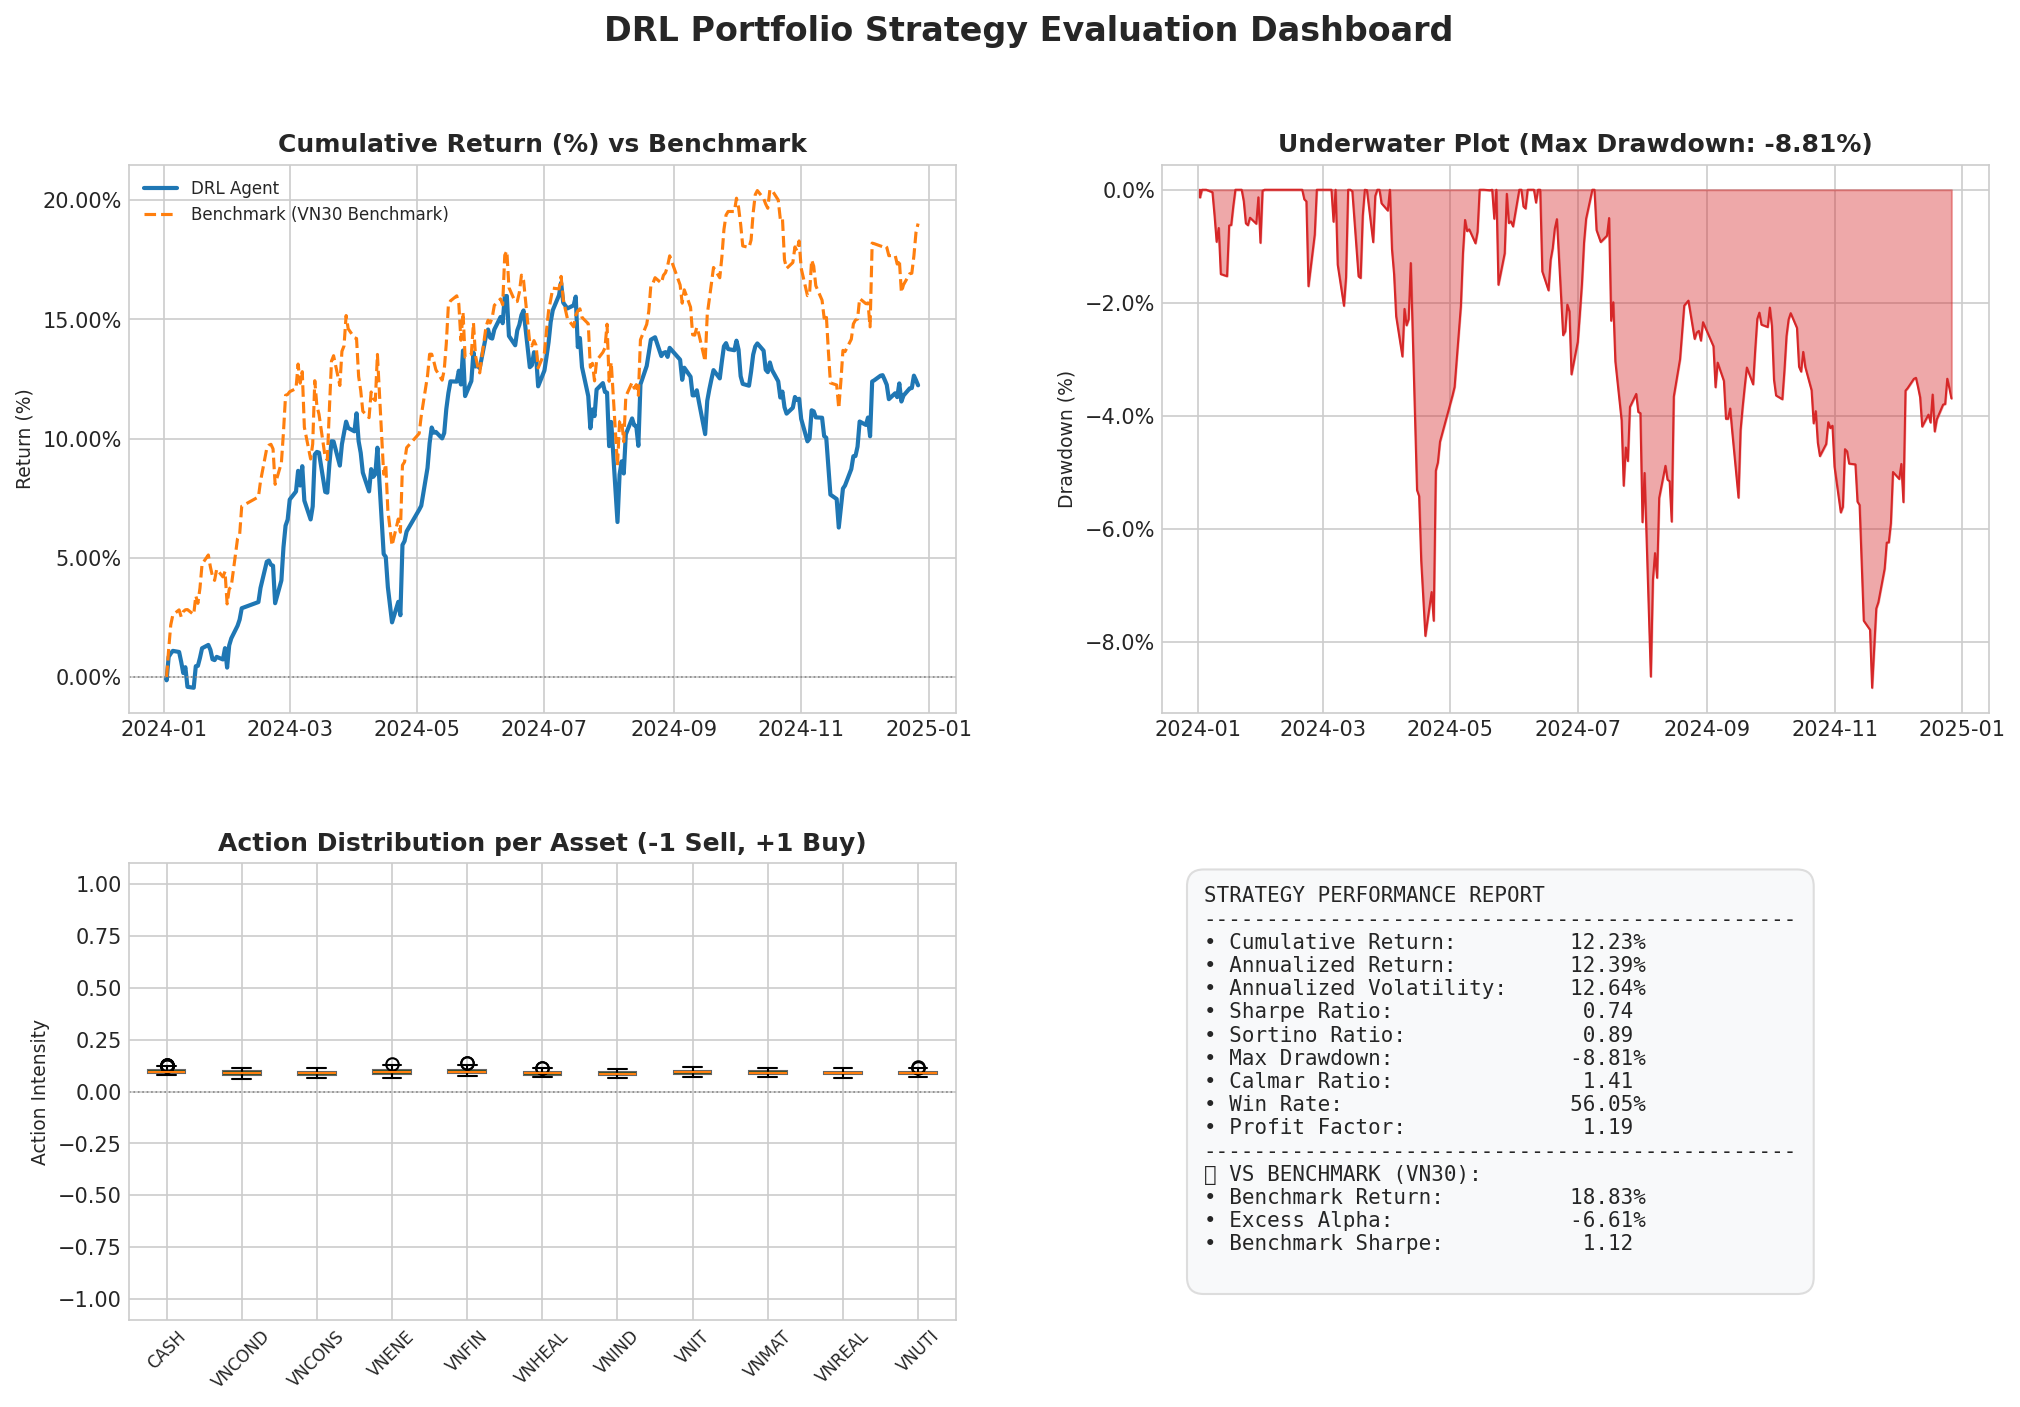

In [4]:
# 1. Khởi tạo ModelVisualizer xuất báo cáo ra thư mục data/reports
reports_dir = os.path.abspath(os.path.join(project_root, "data", "reports"))
visualizer = ModelVisualizer(output_dir=reports_dir)

# 2. Trực quan hóa và xuất Summary Dashboard 2x2 cho tập TEST SET
print("🎨 Đang vẽ biểu đồ trực quan hóa kết quả kiểm thử trên TEST SET...")
dashboard_path, metrics = visualizer.plot_summary_dashboard(
    df_agent=df_account,
    df_actions=df_actions,
    df_benchmark=bm_test_df,
    benchmark_name="VN30 Benchmark",
    save_name="notebook_test_summary_dashboard.png"
)

# 3. Hiển thị bảng chỉ số đo lường hiệu năng Out-of-Sample trên tập TEST SET
metrics_data = [
    {"Chỉ số Hiệu năng (Test Set)": "Lợi nhuận tích lũy (Cumulative Return)", "Giá trị": f"{metrics.get('cumulative_return', 0)*100:.2f}%"},
    {"Chỉ số Hiệu năng (Test Set)": "Lợi nhuận quy năm (Annualized Return)", "Giá trị": f"{metrics.get('annualized_return', 0)*100:.2f}%"},
    {"Chỉ số Hiệu năng (Test Set)": "Biến động quy năm (Annualized Volatility)", "Giá trị": f"{metrics.get('annualized_volatility', 0)*100:.2f}%"},
    {"Chỉ số Hiệu năng (Test Set)": "Tỷ lệ Sharpe (Sharpe Ratio)", "Giá trị": f"{metrics.get('sharpe_ratio', 0):.2f}"},
    {"Chỉ số Hiệu năng (Test Set)": "Tỷ lệ Sortino (Sortino Ratio)", "Giá trị": f"{metrics.get('sortino_ratio', 0):.2f}"},
    {"Chỉ số Hiệu năng (Test Set)": "Mức sụt giảm tối đa (Max Drawdown)", "Giá trị": f"{metrics.get('max_drawdown', 0)*100:.2f}%"},
    {"Chỉ số Hiệu năng (Test Set)": "Tỷ lệ Calmar (Calmar Ratio)", "Giá trị": f"{metrics.get('calmar_ratio', 0):.2f}"},
    {"Chỉ số Hiệu năng (Test Set)": "Tỷ lệ Thắng (Win Rate)", "Giá trị": f"{metrics.get('win_rate', 0)*100:.2f}%"}
]
metrics_df = pd.DataFrame(metrics_data)

print("\n📋 BẢNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST SET (OUT-OF-SAMPLE):")
display(metrics_df)

# 4. Hiển thị hình ảnh Dashboard trực tiếp trong Notebook
print(f"\n🖼️ BIỂU ĐỒ TEST SET EVALUATION DASHBOARD (Lưu tại: {dashboard_path}):")
display(Image(filename=dashboard_path))